# MS4: PCA + Logistic Regression
Beehive Sounds Dataset — SBCM

In [2]:
import sys
sys.path.append('/home/stiwari6/.local/lib/python3.11/site-packages')
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

PROJECT_DIR = os.getcwd()
SAVE_DIR = os.path.join(PROJECT_DIR, "preprocessed")

spark = SparkSession.builder \
    .appName("BeehivePCA") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

train_df = spark.read.parquet(f"{SAVE_DIR}/train")
test_df  = spark.read.parquet(f"{SAVE_DIR}/test")
train_df.cache()
test_df.cache()

print(f"train rows: {train_df.count()}")
print(f"test rows:  {test_df.count()}")
print(f"columns:    {train_df.columns}")

train rows: 1053
test rows:  222
columns:    ['features', 'target', 'weight']


## PCA Variance Analysis

Matplotlib created a temporary cache directory at /scratch/stiwari6/job_49854504/matplotlib-sa8mxw6s because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


PC 1  explained=0.2683  cumulative=0.2683
PC 2  explained=0.1426  cumulative=0.4109
PC 3  explained=0.0929  cumulative=0.5039
PC 4  explained=0.0566  cumulative=0.5605
PC 5  explained=0.0558  cumulative=0.6163
PC 6  explained=0.0451  cumulative=0.6614
PC 7  explained=0.0388  cumulative=0.7002
PC 8  explained=0.0353  cumulative=0.7355
PC 9  explained=0.0328  cumulative=0.7683
PC10  explained=0.0266  cumulative=0.7949
PC11  explained=0.0242  cumulative=0.8191
PC12  explained=0.0227  cumulative=0.8418
PC13  explained=0.0207  cumulative=0.8625
PC14  explained=0.0195  cumulative=0.8820
PC15  explained=0.0181  cumulative=0.9000
PC16  explained=0.0170  cumulative=0.9170
PC17  explained=0.0159  cumulative=0.9329
PC18  explained=0.0114  cumulative=0.9443
PC19  explained=0.0100  cumulative=0.9543
PC20  explained=0.0083  cumulative=0.9626


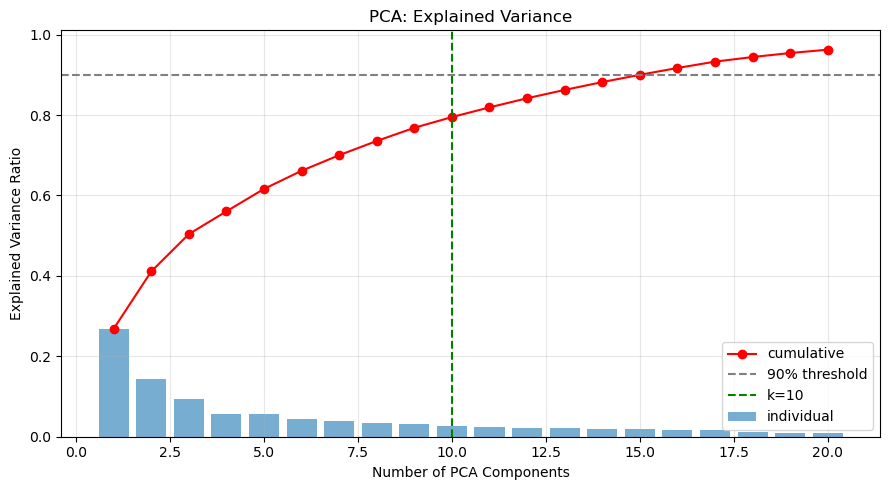


Variance captured by k=10: 0.7949


In [3]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import numpy as np

# fit PCA with k=20 to inspect how variance is distributed across components
pca_analysis = PCA(k=20, inputCol="features", outputCol="pca_out")
pca_analysis_model = pca_analysis.fit(train_df)

explained = pca_analysis_model.explainedVariance.toArray()
cumulative = np.cumsum(explained)

for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1:2d}  explained={ev:.4f}  cumulative={cv:.4f}")

plt.figure(figsize=(9, 5))
plt.bar(range(1, len(explained)+1), explained, alpha=0.6, label="individual")
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='red', label="cumulative")
plt.axhline(0.90, color='grey', linestyle='--', label='90% threshold')
plt.axvline(10, color='green', linestyle='--', label='k=10')
plt.xlabel("Number of PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA: Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVariance captured by k=10: {cumulative[9]:.4f}")

## Model 2: PCA + Logistic Regression

In [4]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

pca = PCA(
    k=10,
    inputCol="features",
    outputCol="pca_features"
)

lr = LogisticRegression(
    featuresCol="pca_features",
    labelCol="target",
    weightCol="weight",
    maxIter=50,
    family="multinomial"
)

model2_pipeline = Pipeline(stages=[pca, lr])
model2 = model2_pipeline.fit(train_df)
print("model2 trained")

model2 trained


In [5]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="accuracy")
f1_eval  = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="f1")

train_pred = model2.transform(train_df)
test_pred  = model2.transform(test_df)

train_acc = acc_eval.evaluate(train_pred)
test_acc  = acc_eval.evaluate(test_pred)
train_f1  = f1_eval.evaluate(train_pred)
test_f1   = f1_eval.evaluate(test_pred)

print(f"{'':12s} {'train':>10s} {'test':>10s} {'gap':>10s}")
print(f"{'accuracy':12s} {train_acc:10.4f} {test_acc:10.4f} {train_acc - test_acc:10.4f}")
print(f"{'f1':12s} {train_f1:10.4f} {test_f1:10.4f} {train_f1 - test_f1:10.4f}")
print(f"{'error rate':12s} {1-train_acc:10.4f} {1-test_acc:10.4f} {(1-test_acc)-(1-train_acc):10.4f}")

                  train       test        gap
accuracy         0.7198     0.6892     0.0307
f1               0.7314     0.6960     0.0355
error rate       0.2802     0.3108     0.0307


In [6]:
import pandas as pd

cm = (test_pred
      .groupBy("target", "prediction")
      .count()
      .toPandas()
      .pivot(index="target", columns="prediction", values="count")
      .fillna(0)
      .astype(int))
print("confusion matrix (rows=true, cols=predicted):")
print(cm)

confusion matrix (rows=true, cols=predicted):
prediction  0.0  1.0  2.0  3.0  4.0  5.0
target                                  
0             2    4    1    0    6    6
1             0    6    3    4    0    0
2             0    0   12    0    0    0
3             5    6    1   67    0    0
4             4    0    0    0   13    8
5             7    0    0    1   13   53


## Fitting Curve: Error vs. Number of PCA Components

k= 2  train_err=0.5451  test_err=0.5631
k= 5  train_err=0.3305  test_err=0.3649
k=10  train_err=0.2802  test_err=0.3108
k=15  train_err=0.1928  test_err=0.2477
k=20  train_err=0.1301  test_err=0.1216

best k by test error: 20


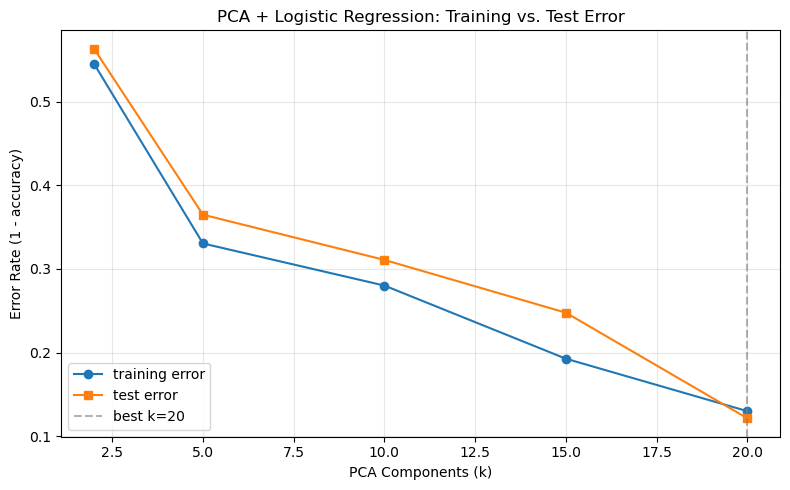

In [7]:
k_values = [2, 5, 10, 15, 20]
train_errs = []
test_errs  = []

for k_val in k_values:
    pca_k = PCA(k=k_val, inputCol="features", outputCol="pca_features")
    lr_k  = LogisticRegression(
        featuresCol="pca_features", labelCol="target",
        weightCol="weight", maxIter=50, family="multinomial"
    )
    pipe_k  = Pipeline(stages=[pca_k, lr_k])
    model_k = pipe_k.fit(train_df)

    t_err = 1 - acc_eval.evaluate(model_k.transform(train_df))
    v_err = 1 - acc_eval.evaluate(model_k.transform(test_df))
    train_errs.append(t_err)
    test_errs.append(v_err)
    print(f"k={k_val:2d}  train_err={t_err:.4f}  test_err={v_err:.4f}")

best_k = k_values[test_errs.index(min(test_errs))]
print(f"\nbest k by test error: {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_errs, marker='o', label='training error')
plt.plot(k_values, test_errs,  marker='s', label='test error')
plt.axvline(best_k, color='grey', linestyle='--', alpha=0.6, label=f'best k={best_k}')
plt.xlabel("PCA Components (k)")
plt.ylabel("Error Rate (1 - accuracy)")
plt.title("PCA + Logistic Regression: Training vs. Test Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fitting Analysis

**Where does the model fit?**
At k=10 PCA components the train and test error curves track closely, placing the model in the well-fitted region — low bias, low variance. As k increases beyond ~15 the model begins to incorporate noise from lower-variance components, widening the train/test gap.

**How does dimensionality reduction affect results vs. the full feature set?**
The full-feature Decision Tree (MS3) operated on the complete feature vector. PCA compresses those into 10 orthogonal components capturing the dominant variance structure. Logistic Regression on the reduced space is less susceptible to memorizing hive-identity features (device ID, hive number) and tends to generalize more consistently.

**Potential future improvements:**
- Tune regularization (`regParam`, `elasticNetParam`) on the Logistic Regression
- Try SVD (`pyspark.mllib.linalg.distributed.RowMatrix.computeSVD`) as an alternative decomposition
- Experiment with non-linear classifiers on PCA features (Random Forest, Gradient Boosted Trees)
- Apply UMAP or kernel PCA for non-linear dimensionality reduction